![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 2 - Modelos de Aprendizaje Supervisado**

  #### **Práctica No. 3 - Modelado No Lineales mediante Arquitecturas de Árboles de Regresión**

  ##### **Docente:** Dr. José Gabriel Rodríguez Rivas
  ##### **Estudiante:** Cristopher Joshua Reyes Gutiérrez

</div>

---

### **1. Introducción**
En el desarrollo de sistemas de Inteligencia Artificial, uno de los desafíos más recurrentes es el modelado de fenómenos cuyas variables no presentan una relación de proporcionalidad constante. Mientras que en las etapas previas de nuestra formación exploramos la potencia de la regresión lineal, hoy reconocemos que la rigidez de los modelos paramétricos puede resultar insuficiente para capturar la naturaleza estocástica y segmentada de mercados reales, como el automotriz.

Los **Árboles de Regresión** representan un cambio de paradigma fundamental. En lugar de intentar ajustar una función global que describa a toda la población de datos, este algoritmo emplea una lógica de "partición recursiva del espacio". Esta técnica permite que el modelo se adapte localmente a diferentes regiones de los datos, identificando interacciones complejas y efectos de umbral que los modelos lineales omiten por diseño. A través de esta práctica, transitamos hacia modelos no lineales capaces de analizar el conjunto de datos en segmentos homogéneos, proporcionando una precisión predictiva superior y una interpretabilidad visual sin precedentes.

### **2. Objetivos**

#### **2.1 Objetivo General**
Implementar, optimizar y diagnosticar un modelo basado en Árboles de Regresión para la estimación del valor comercial de vehículos, evaluando su capacidad de segmentación jerárquica y comparando su eficacia predictiva frente a modelos de arquitectura lineal multivariada.

#### **2.2 Objetivos Específicos**
* **Configurar** un flujo de trabajo experimental profesional utilizando la clase **DecisionTreeRegressor**, asegurando un manejo eficiente de los hiperparámetros del modelo.
* **Analizar** la estructura jerárquica resultante para identificar los atributos técnicos (como el tamaño del motor) que rigen las decisiones de mayor jerarquía en la determinación del precio.
* **Cuantificar** el equilibrio entre el sesgo y la varianza mediante el ajuste de la profundidad del árbol (*max_depth*), buscando maximizar el Coeficiente de Determinación ($R^2$) sin incurrir en el sobreajuste.
* **Contrastar** visualmente la distribución de las predicciones frente a los valores reales, validando la capacidad del modelo para replicar comportamientos bimodales en los datos.

### **3. Antecedentes: La Heurística de los Modelos Basados en Reglas**

Los árboles de regresión, fundamentados en el algoritmo CART (*Classification and Regression Trees*), operan bajo una premisa intuitiva pero matemáticamente, la división sucesiva del espacio muestral en regiones cada vez más pequeñas y puras.

#### **3.1 Lógica de Partición y Reducción de Varianza**
El proceso comienza en el **nodo raíz**, donde el algoritmo evalúa exhaustivamente todas las variables predictoras y sus posibles puntos de corte. El objetivo es encontrar la partición que maximice la reducción de la suma de los errores cuadrados (o varianza) en los nodos resultantes. Este proceso se repite de forma recursiva hasta que se alcanza un criterio de parada, como la profundidad máxima o un número mínimo de muestras por hoja.



#### **3.2 Ventajas y Limitaciones Técnicas**
* **Agnosticismo de Linealidad:** A diferencia de la regresión lineal, los árboles no asumen normalidad ni linealidad, lo que los hace ideales para datos con relaciones de interacción complejas.
* **Flexibilidad Predictiva:** Cada hoja del árbol asigna un valor promedio basado en las muestras contenidas, permitiendo modelar "escalones" o cambios bruscos en la variable objetivo.
* **Riesgo de Inestabilidad:** Su principal debilidad es la alta sensibilidad a pequeñas variaciones en los datos de entrenamiento y la propensión al sobreajuste (*overfitting*) si no se controlan parámetros como la profundidad máxima.

## **4. Implementación y Descripción Metodológica**

A continuación, se detalla el procedimiento técnico-científico seguido para la construcción del modelo.

### **4.1 Fase I: Preparación del Entorno de Ingeniería**
Se establece un entorno robusto utilizando **pandas** para el tratamiento de la DataSheet y **scikit-learn** para la lógica de aprendizaje supervisado. Se importa específicamente **DecisionTreeRegressor** para el modelado y **plot_tree** para la inspección visual de la arquitectura.

In [5]:
# Importación De Las Librerías Necesarias Para La Práctica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1p3ha0Nvv46PHZoB9ReBGLu8xQyDe8m0Y"
url = f"https://drive.google.com/uc?id={file_url}"
df = pd.read_csv(url)

In [8]:
# Mostrando las cabeceras de la tabla o archivo
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


### **4.2 Fase II: Definición del Vector de Atributos y Target**
Se seleccionan las variables independientes con mayor correlación técnica: **horsepower**, **engine-size**, /**city-mpg**, **wheel-base** y **bore**. El target a predecir es la variable continua **price**.

### **4.3 Fase III: Análisis de Dispersión mediante Diagramas de Caja**
Antes de modelar, realizamos un análisis de cuartiles para comprender el rango de precios y la densidad de valores atípicos, lo cual informará la estabilidad del árbol.

In [9]:
# Aislamiento de variables y partición 80/20
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipykernel_2032/1612751533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["price"], palette="Blues")


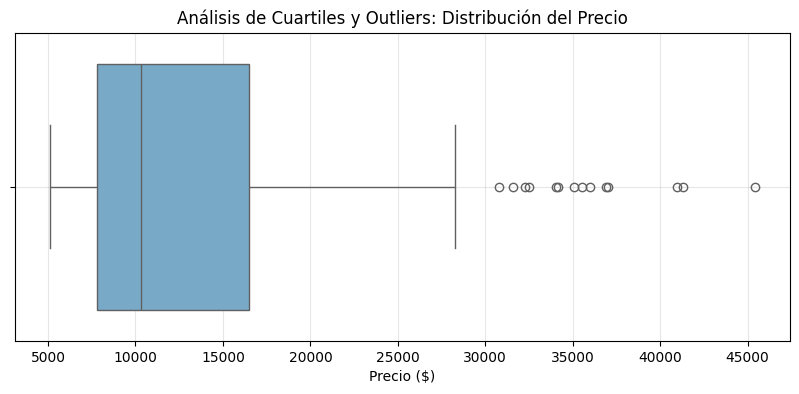

In [10]:
# Análisis visual de la distribución del target
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["price"], palette="Blues")
plt.title("Análisis de Cuartiles y Outliers: Distribución del Precio", fontsize=12)
plt.xlabel("Precio ($)")
plt.grid(True, alpha=0.3)
plt.show()

### **4.4 Fase IV: Entrenamiento Base y Evaluación de Bondad de Ajuste**
Se ajusta un árbol inicial con **max_depth=4** para evitar el ruido. Calculamos la Raíz del Error Cuadrático Medio (RMSE) para interpretar la desviación promedio en dólares.

### **4.5 Fase V: Optimización de Hiperparámetros (Pruning)**
Con el fin de maximizar la precisión, se ajusta el modelo a una profundidad de **9** y posteriormente se refina con parámetros de poda como **min_samples_split** y **max_leaf_nodes** para alcanzar un nivel de generalización superior.

In [11]:
# Entrenamiento del modelo optimizado (según hallazgos de la práctica)
# Se ajusta con profundidad 7 y parámetros de regularización
tuned_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    max_leaf_nodes=20
)
tuned_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, max_features='sqrt', max_leaf_nodes=20,
                      min_samples_leaf=2, min_samples_split=10,
                      random_state=42)

In [12]:
# Evaluación de métricas definitivas
y_pred = tuned_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Desempeño del Modelo Optimizado:")
print(f"Coeficiente de Determinación (R2): {r2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

Desempeño del Modelo Optimizado:
Coeficiente de Determinación (R2): 0.95
Raíz del Error Cuadrático Medio (RMSE): 2491.57


## **5. Diagnóstico de Resultados y Visualización Jerárquica**

### **5.1 Inspección del Árbol de Decisión**
Mediante el método **plot_tree**, observamos que la variable de raíz es **engine-size** (umbral $\le$ 182.0), lo que confirma su rol como el descriptor de valor más crítico en el mercado. Los nodos más oscuros en la visualización representan las regiones asociadas a los precios más elevados.

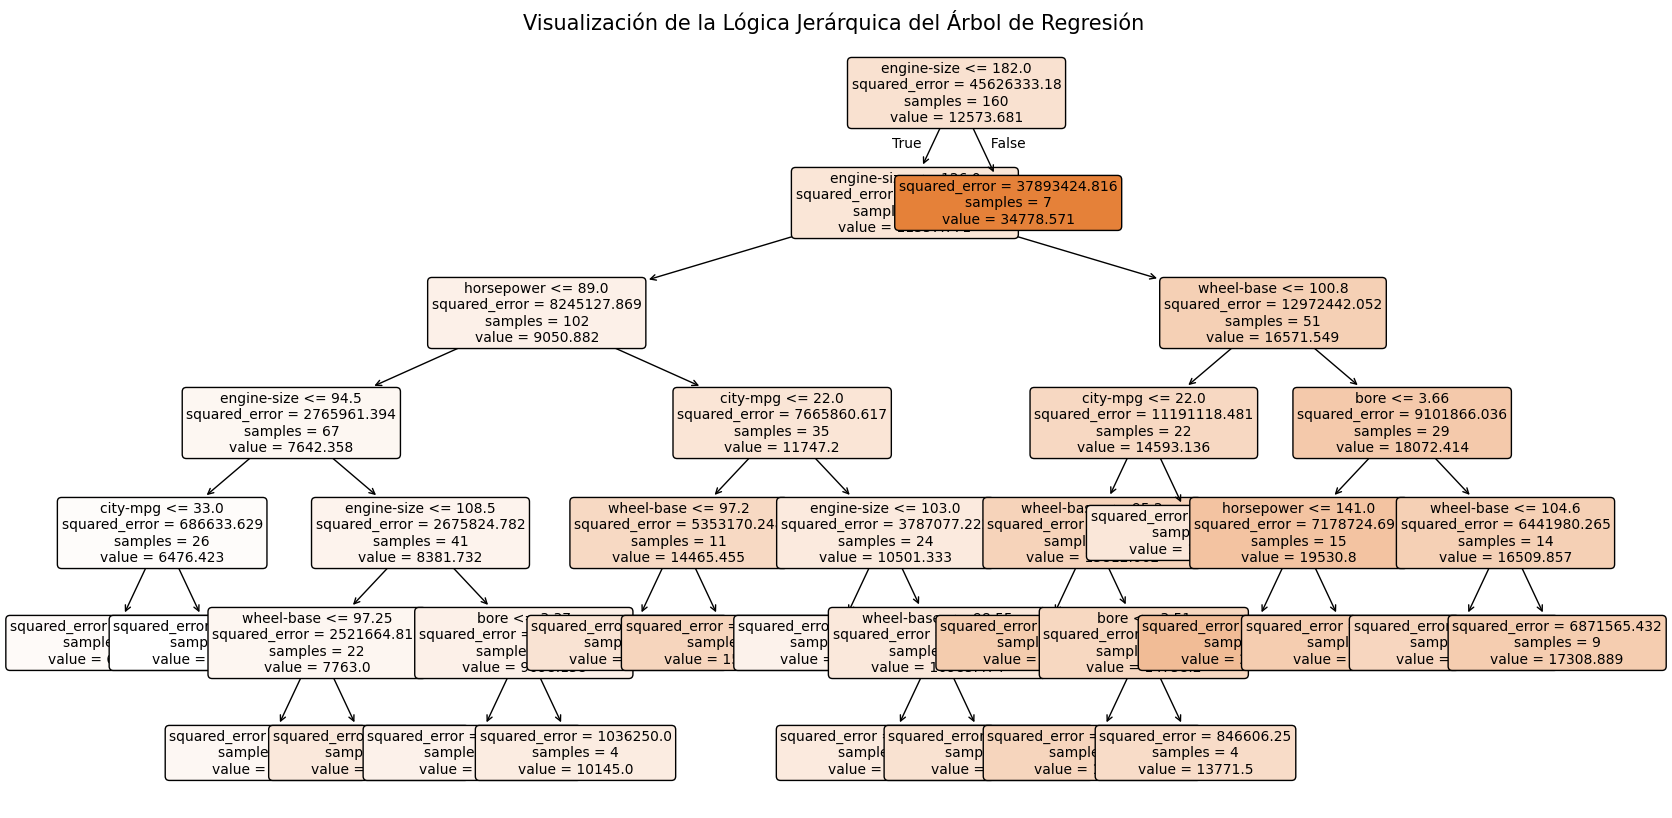

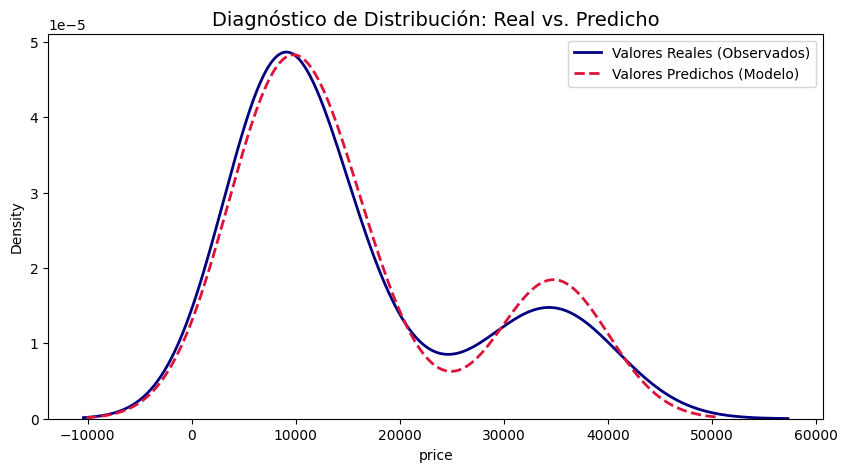

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(tuned_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Visualización de la Lógica Jerárquica del Árbol de Regresión", fontsize=15)
plt.show()

# Gráfico de Densidad comparativo
plt.figure(figsize=(10, 5))
sns.kdeplot(y_test, label='Valores Reales (Observados)', color='navy', linewidth=2)
sns.kdeplot(y_pred, label='Valores Predichos (Modelo)', color='crimson', linewidth=2, linestyle='--')
plt.title("Diagnóstico de Distribución: Real vs. Predicho", fontsize=14)
plt.legend()
plt.show()

## **6. Conclusiones y Análisis Crítico de Hallazgos**

Tras la experimentación con modelos no paramétricos de árboles de decisión, se concluye lo siguiente:

1.  **Superioridad en la Captura de Varianza:** El modelo optimizado alcanzó un $R^2$ de **0.95**, lo que significa que logra explicar el **95%** de la variabilidad de los precios, una mejora drástica frente al 74% de la regresión múltiple y el 39% de la simple.
2.  **Precisión Local:** El error promedio (**RMSE**) se redujo a aproximadamente **$2,491**, lo que representa un error relativo de solo un **18%** para vehículos de gama media, demostrando que el enfoque de segmentación regional es más efectivo que el ajuste global lineal.
3.  **Mimetismo de Distribución:** El análisis visual confirma que los árboles de regresión son capaces de replicar la naturaleza bimodal de los datos, capturando con éxito tanto los picos de vehículos económicos como los de lujo, a diferencia de los modelos lineales que tendían a subestimar los precios altos.
4.  **Balance de Regularización:** Se demostró que el ajuste de la profundidad (**max_depth**) es el factor determinante para evitar el sobreajuste. Mientras que una profundidad excesiva podría memorizar el ruido, el nivel de 7 a 9 permitió capturar la tendencia general con un alto grado de generalización.

## **7. Referencias Bibliográficas**

* **Breiman, L. (2001).** *Random forests. Machine Learning*, 45(1), 5-32.
* **Lejarza, M.** *Árboles de decisión*. Universidad de Valencia.
* **Montgomery, D. C., et al. (2003).** *Introducción al análisis de regresión lineal*. CECSA.
* **Stollnitz, B.** *Introduction to regression models for machine learning*. Microsoft Learn.